Loading feature data from: /home/src/deeplerning_model/CNNvsmine/feature_huall.csv
特徴量データ数: 1038

Total Size: 18 (Actual: 18)
Looking for ResNet CSV: /home/src/deeplerning_model/CNNvsmine/resnet18_cv_total18/resnet_evaluation_details.csv
  ResNetデータ数: 18
  結合後データ数: 18
  -> Average SVM Accuracy: 0.3889

Total Size: 30 (Actual: 30)
Looking for ResNet CSV: /home/src/deeplerning_model/CNNvsmine/resnet18_cv_total30/resnet_evaluation_details.csv
  ResNetデータ数: 30
  結合後データ数: 30
  -> Average SVM Accuracy: 0.4667

Total Size: 42 (Actual: 42)
Looking for ResNet CSV: /home/src/deeplerning_model/CNNvsmine/resnet18_cv_total42/resnet_evaluation_details.csv
  ResNetデータ数: 42
  結合後データ数: 42
  -> Average SVM Accuracy: 0.4286

Total Size: 54 (Actual: 54)
Looking for ResNet CSV: /home/src/deeplerning_model/CNNvsmine/resnet18_cv_total54/resnet_evaluation_details.csv
  ResNetデータ数: 54
  結合後データ数: 54
  -> Average SVM Accuracy: 0.5185

Total Size: 72 (Actual: 72)
Looking for ResNet CSV: /home/src/deeplerning_mode

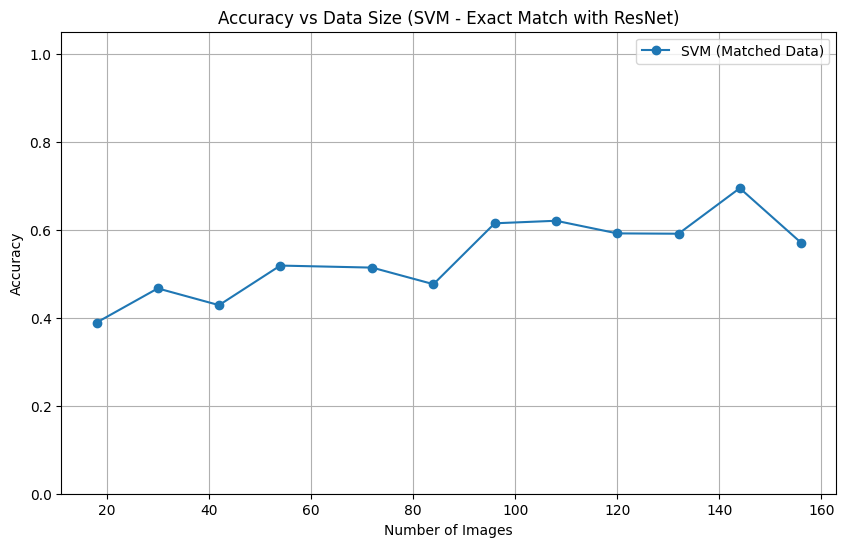

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

def main():
    # ==========================================
    # 1. 設定パラメータ
    # ==========================================
    # 特徴量CSVのパス
    FEATURE_CSV_PATH = "/home/data/0107_tomine/feature_huall.csv"
    
    # ResNetの実験結果が保存されている親ディレクトリ
    RESNET_RESULT_BASE_DIR = "/home/src/deeplerning_model/CNNvsmine" 
    
    # 出力先
    OUTPUT_DIR = RESNET_RESULT_BASE_DIR
    
    # SVMで使用する特徴量
    FEATURE_COLS = ['size_count', 'R', 'h0', 'h2', 'h3', 'h7']
    
    # 比較対象のデータサイズ (ResNetの実験フォルダ名に対応)
    # TARGET_TOTAL_SIZES = [18, 30, 42, 54,66, 72, 84, 96, 108, 120, 132, 144, 156]
    TARGET_TOTAL_SIZES = [18, 30, 42, 54,66, 72]

    
    NUM_CLASSES = 3
    
    print(f"Loading feature data from: {FEATURE_CSV_PATH}")
    if not os.path.exists(FEATURE_CSV_PATH):
        print("エラー: 特徴量CSVが見つかりません。")
        return

    # 2. 特徴量データの読み込みと前処理
    df_features = pd.read_csv(FEATURE_CSV_PATH)
    
    if 'filename' in df_features.columns:
        df_features['match_key'] = df_features['filename'].astype(str).str.replace('_mask', '').str.replace('.png', '')
    else:
        print("エラー: 特徴量CSVに filename 列がありません")
        return

    # 欠損値削除
    df_features = df_features.dropna(subset=FEATURE_COLS).reset_index(drop=True)
    
    # 重複排除
    df_features = df_features.drop_duplicates(subset=['match_key'])
    
    print(f"特徴量データ数: {len(df_features)}")

    global_results = []
    
    # 3. データサイズごとのループ
    for total_size in TARGET_TOTAL_SIZES:
        IMAGES_PER_CLASS = total_size // NUM_CLASSES
        ACTUAL_TOTAL = IMAGES_PER_CLASS * NUM_CLASSES
        
        resnet_dir = os.path.join(RESNET_RESULT_BASE_DIR, f'resnet18_cv_total{ACTUAL_TOTAL}')
        resnet_csv = os.path.join(resnet_dir, 'resnet_evaluation_details.csv')
        
        print(f"\n========================================")
        print(f"Total Size: {total_size} (Actual: {ACTUAL_TOTAL})")
        print(f"Looking for ResNet CSV: {resnet_csv}")
        
        if not os.path.exists(resnet_csv):
            print(f"  警告: CSVが見つかりません。このサイズはスキップします。")
            continue
            
        df_resnet = pd.read_csv(resnet_csv)
        df_resnet['match_key'] = df_resnet['filename'].astype(str).str.replace('_crop', '').str.replace('.png', '')
        
        df_merged = pd.merge(df_resnet, df_features, on='match_key', how='inner', suffixes=('_resnet', '_feature'))
        
        print(f"  ResNetデータ数: {len(df_resnet)}")
        print(f"  結合後データ数: {len(df_merged)}")
        
        if len(df_merged) != len(df_resnet):
            print(f"  注意: 特徴量CSVに存在しない画像が {len(df_resnet) - len(df_merged)} 枚あります。")
        
        # --- Foldごとの評価 ---
        folds = sorted(df_merged['Fold'].unique())
        fold_accuracies = []
        fold_f1s = []
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(class_weight='balanced', random_state=42))
        ])
        
        param_grid = {
            'svm__C': [0.1, 1, 10, 100],
            'svm__gamma': ['scale', 'auto', 0.1, 0.01],
            'svm__kernel': ['rbf']
        }
        
        for fold in folds:
            test_data = df_merged[df_merged['Fold'] == fold]
            train_data = df_merged[df_merged['Fold'] != fold]
            
            if len(test_data) == 0 or len(train_data) == 0:
                print(f"  Skipping Fold {fold} (Not enough data)")
                continue
                
            X_train = train_data[FEATURE_COLS]
            y_train = train_data['True_Label']
            
            X_test = test_data[FEATURE_COLS]
            y_test = test_data['True_Label']
            
            inner_cv = min(3, len(X_train) // NUM_CLASSES)
            if inner_cv < 2: inner_cv = 2
            
            grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
            grid.fit(X_train, y_train)
            
            best_model = grid.best_estimator_
            preds = best_model.predict(X_test)
            
            acc = accuracy_score(y_test, preds)
            report = classification_report(y_test, preds, output_dict=True, zero_division=0)
            macro_f1 = report['macro avg']['f1-score']
            
            fold_accuracies.append(acc)
            fold_f1s.append(macro_f1)

        avg_acc = np.mean(fold_accuracies) if fold_accuracies else 0
        avg_f1 = np.mean(fold_f1s) if fold_f1s else 0
        
        print(f"  -> Average SVM Accuracy: {avg_acc:.4f}")
        
        global_results.append({
            'Total_Images': ACTUAL_TOTAL,
            'Requested_Images': total_size,
            'SVM_Accuracy': avg_acc,
            'SVM_Macro_F1': avg_f1
        })

    # 4. 結果保存
    if global_results:
        results_df = pd.DataFrame(global_results)
        save_path = os.path.join(OUTPUT_DIR, "svm_results_matched_with_resnet.csv")
        results_df.to_csv(save_path, index=False)
        print(f"\nSaved matched results to: {save_path}")
        
        # グラフ作成 (範囲変更)
        plt.figure(figsize=(10, 6))
        plt.plot(results_df['Total_Images'], results_df['SVM_Accuracy'], marker='o', label='SVM (Matched Data)')
        plt.title('Accuracy vs Data Size (SVM - Exact Match with ResNet)')
        plt.xlabel('Number of Images')
        plt.ylabel('Accuracy')
        plt.grid(True)
        plt.legend()
        
        # ★ここを変更: y軸の範囲を 0.2 〜 1.0 に設定
        plt.ylim(0, 1.05) 
        
        plt.savefig(os.path.join(OUTPUT_DIR, "svm_accuracy_plot_matched.png"))
        print("Graph saved.")

if __name__ == "__main__":
    main()

Loading ResNet results: /home/src/deeplerning_model/CNNvsmine/final_size_accuracy_comparison.csv
Loading SVM results: /home/src/deeplerning_model/CNNvsmine/svm_size_accuracy_comparison.csv

グラフを保存しました: /home/src/deeplerning_model/CNNvsmine/comparison_resnet_vs_svm.png


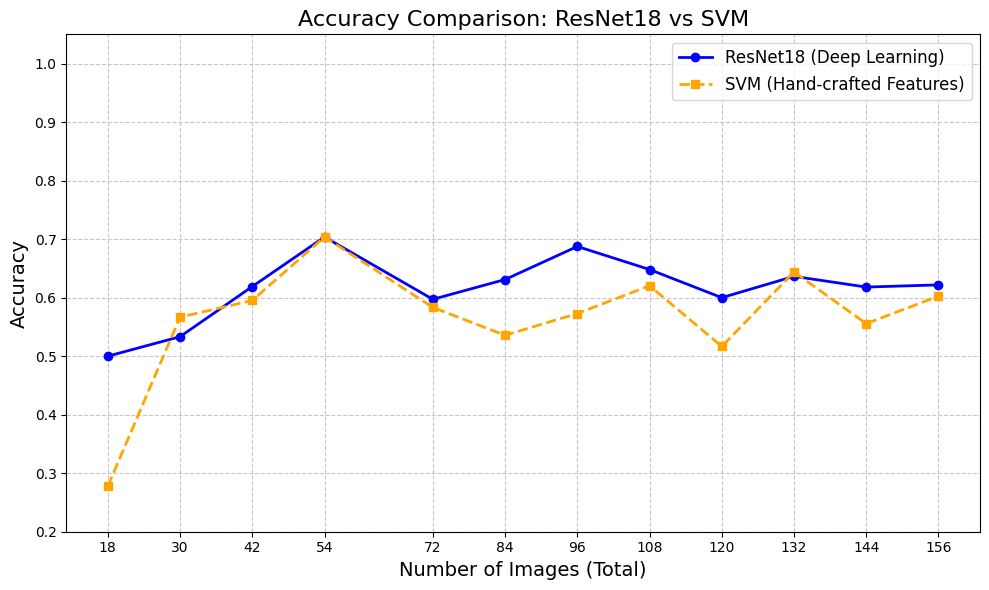

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def main():
    # ==========================================
    # 1. ファイルパスの設定
    # ==========================================
    # 結果が保存されているディレクトリ
    BASE_DIR = "/home/src/deeplerning_model/CNNvsmine"
    
    # ResNetの結果CSV (Average_Accuracy 列がある想定)
    RESNET_CSV = os.path.join(BASE_DIR, "final_size_accuracy_comparison.csv")
    
    # SVMの結果CSV (SVM_Accuracy 列がある想定)
    # SVM_CSV = os.path.join(BASE_DIR, "svm_results_matched_with_resnet.csv")
    SVM_CSV = os.path.join(BASE_DIR, "svm_size_accuracy_comparison.csv")
    
    # グラフの保存先
    OUTPUT_FILE = os.path.join(BASE_DIR, "comparison_resnet_vs_svm.png")

    # ==========================================
    # 2. データの読み込み
    # ==========================================
    print(f"Loading ResNet results: {RESNET_CSV}")
    if not os.path.exists(RESNET_CSV):
        print(f"エラー: ResNetのCSVが見つかりません: {RESNET_CSV}")
        return
    df_resnet = pd.read_csv(RESNET_CSV)

    print(f"Loading SVM results: {SVM_CSV}")
    if not os.path.exists(SVM_CSV):
        print(f"エラー: SVMのCSVが見つかりません: {SVM_CSV}")
        return
    df_svm = pd.read_csv(SVM_CSV)

    # データのソート (念のためデータ数順に並べる)
    df_resnet = df_resnet.sort_values('Total_Images')
    df_svm = df_svm.sort_values('Total_Images')

    # ==========================================
    # 3. グラフの描画
    # ==========================================
    plt.figure(figsize=(10, 6))

    # --- ResNetのプロット (青色) ---
    # CSVのカラム名を確認してください。通常は 'Average_Accuracy' です
    plt.plot(
        df_resnet['Total_Images'], 
        df_resnet['Average_Accuracy'], 
        marker='o', linestyle='-', color='blue', linewidth=2,
        label='ResNet18 (Deep Learning)'
    )

    # --- SVMのプロット (オレンジ色) ---
    # CSVのカラム名を確認してください。前回のコードでは 'SVM_Accuracy' です
    plt.plot(
        df_svm['Total_Images'], 
        df_svm['SVM_Accuracy'], 
        marker='s', linestyle='--', color='orange', linewidth=2,
        label='SVM (Hand-crafted Features)'
    )

    # ==========================================
    # 4. グラフの装飾
    # ==========================================
    plt.title('Accuracy Comparison: ResNet18 vs SVM', fontsize=16)
    plt.xlabel('Number of Images (Total)', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    
    # 凡例を表示
    plt.legend(fontsize=12)
    
    # グリッド表示
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 軸の範囲設定 (ご要望通り 0.2 〜 1.0)
    plt.ylim(0.2, 1.05)
    
    # 横軸の目盛りをデータ数に合わせる (見やすくするため)
    all_ticks = sorted(list(set(df_resnet['Total_Images']) | set(df_svm['Total_Images'])))
    plt.xticks(all_ticks)

    # ==========================================
    # 5. 保存
    # ==========================================
    plt.tight_layout()
    plt.savefig(OUTPUT_FILE, dpi=300)
    print(f"\nグラフを保存しました: {OUTPUT_FILE}")
    
    # 画面に表示 (環境によっては表示されないので保存を優先)
    # plt.show()

if __name__ == "__main__":
    main()

Loading data from: /home/src/deeplerning_model/CNNvsmine/feature_huall.csv
有効データ数: 1038件
  Class 0: 496 images
  Class 1: 302 images
  Class 2: 240 images

★ 実験開始: 目標データ総数 18枚
  学習・評価に使用するデータ数: 18枚
  -> 平均正解率 (Accuracy): 0.2778
  -> 平均F1 (Macro): 0.2037

★ 実験開始: 目標データ総数 30枚
  学習・評価に使用するデータ数: 30枚
  -> 平均正解率 (Accuracy): 0.5667
  -> 平均F1 (Macro): 0.5019

★ 実験開始: 目標データ総数 42枚
  学習・評価に使用するデータ数: 42枚
  -> 平均正解率 (Accuracy): 0.5952
  -> 平均F1 (Macro): 0.5124

★ 実験開始: 目標データ総数 54枚
  学習・評価に使用するデータ数: 54枚
  -> 平均正解率 (Accuracy): 0.7037
  -> 平均F1 (Macro): 0.6972

★ 実験開始: 目標データ総数 72枚
  学習・評価に使用するデータ数: 72枚
  -> 平均正解率 (Accuracy): 0.5833
  -> 平均F1 (Macro): 0.5616

★ 実験開始: 目標データ総数 84枚
  学習・評価に使用するデータ数: 84枚
  -> 平均正解率 (Accuracy): 0.5357
  -> 平均F1 (Macro): 0.4992

★ 実験開始: 目標データ総数 96枚
  学習・評価に使用するデータ数: 96枚
  -> 平均正解率 (Accuracy): 0.5729
  -> 平均F1 (Macro): 0.5542

★ 実験開始: 目標データ総数 108枚
  学習・評価に使用するデータ数: 108枚
  -> 平均正解率 (Accuracy): 0.6204
  -> 平均F1 (Macro): 0.6005

★ 実験開始: 目標データ総数 120枚
  学習・評価に使用するデータ数: 120枚
  -> 平

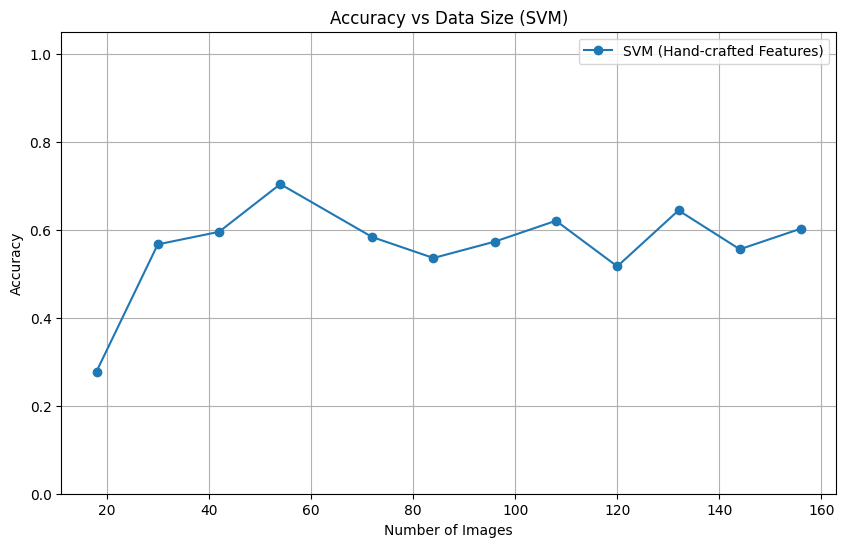

In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

def main():
    # ==========================================
    # 1. 設定パラメータ
    # ==========================================
    # ユーザー指定のCSVパス
    CSV_PATH = "/home/src/deeplerning_model/CNNvsmine/feature_huall.csv"
    
    # 保存先ディレクトリ (CSVと同じ場所に出力します)
    OUTPUT_DIR = os.path.dirname(CSV_PATH)
    
    # 使用する特徴量
    FEATURE_COLS = ['size_count', 'R', 'h0', 'h2', 'h3', 'h7']
    
    # ResNet実験と同じ比較条件
    TARGET_TOTAL_SIZES = [18, 30, 42, 54, 72, 84, 96, 108, 120, 132, 144, 156]
    K_FOLDS = 6
    NUM_CLASSES = 3
    RANDOM_STATE_KFOLD = 42

    print(f"Loading data from: {CSV_PATH}")
    if not os.path.exists(CSV_PATH):
        print("エラー: CSVファイルが見つかりません。パスを確認してください。")
        return

    # 2. データの読み込みと前処理
    df = pd.read_csv(CSV_PATH)
    
    # ファイル名のクリーニング
    # ResNet側は "IMG_1234.png" のようなファイル名を使っているはずですが、
    # 今回のCSVは "IMG_1234_mask.png" となっているため、_mask を除去して整合性を取ります。
    # ※もしResNet側もマスク画像名を使っているなら、この置換は不要ですが、念のため正規化します。
    if 'filename' in df.columns:
        df['clean_filename'] = df['filename'].str.replace('_mask', '', regex=False)
    else:
        print("エラー: CSVに 'filename' カラムがありません。")
        return

    # クラスラベルの確認 (CSVのLabel列を使用)
    if 'Label' not in df.columns:
        # category列からLabelを作成する場合のバックアップ処理
        if 'category' in df.columns:
            categories = sorted(df['category'].unique())
            cat_to_label = {cat: i for i, cat in enumerate(categories)}
            df['Label'] = df['category'].map(cat_to_label)
            print(f"Label列を作成しました: {cat_to_label}")
        else:
            print("エラー: CSVに 'Label' または 'category' カラムがありません。")
            return

    # 欠損値チェック (特徴量がNaNの行を削除)
    df = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
    print(f"有効データ数: {len(df)}件")

    # === 重要: ResNetのデータ読み込み順序を再現するためのソート ===
    # ImageFolderはファイル名順に画像を読み込むため、こちらもクラスごとにファイル名でソートします。
    df_by_class = {}
    for label in range(NUM_CLASSES):
        # クラスごとのデータを抽出し、ファイル名(clean_filename)でソート
        sub_df = df[df['Label'] == label].sort_values('clean_filename').reset_index(drop=True)
        df_by_class[label] = sub_df
        print(f"  Class {label}: {len(sub_df)} images")

    # 結果格納用リスト
    global_results = []

    # 3. データサイズごとの実験ループ
    for total_size_req in TARGET_TOTAL_SIZES:
        print(f"\n========================================")
        print(f"★ 実験開始: 目標データ総数 {total_size_req}枚")
        
        # パラメータ計算 (ResNet実験と完全に一致させる)
        IMAGES_PER_CLASS = total_size_req // NUM_CLASSES
        ACTUAL_TOTAL = IMAGES_PER_CLASS * NUM_CLASSES
        SEED_VALUE = total_size_req # シード値をデータ数と同じにする

        # --- データ抽出ロジック (ResNet再現) ---
        used_dfs = []
        
        # このシード設定が重要
        np.random.seed(SEED_VALUE)
        
        for label in range(NUM_CLASSES):
            class_df = df_by_class[label]
            indices = np.arange(len(class_df))
            
            # データ不足時の処理
            if len(class_df) < IMAGES_PER_CLASS:
                print(f"  警告: Class {label} は {len(class_df)}枚しかありません（{IMAGES_PER_CLASS}枚不足）。全使用します。")
                select_num = len(class_df)
            else:
                select_num = IMAGES_PER_CLASS
            
            # ランダムシャッフルして抽出
            np.random.shuffle(indices)
            selected_indices = indices[:select_num]
            
            used_dfs.append(class_df.iloc[selected_indices])
        
        # 抽出したデータを結合
        current_df = pd.concat(used_dfs, ignore_index=True)
        # 念のためシャッフル (K-Fold前のランダム化)
        current_df = current_df.sample(frac=1, random_state=RANDOM_STATE_KFOLD).reset_index(drop=True)
        
        X = current_df[FEATURE_COLS]
        y = current_df['Label']
        
        print(f"  学習・評価に使用するデータ数: {len(current_df)}枚")

        # --- SVM評価 (K-Fold CV) ---
        skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE_KFOLD)
        
        fold_accuracies = []
        fold_f1s = []
        
        # SVMパイプライン (スケーリング + SVM)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(class_weight='balanced', random_state=RANDOM_STATE_KFOLD))
        ])
        
        # ハイパーパラメータ探索範囲
        param_grid = {
            'svm__C': [0.1, 1, 10, 100],
            'svm__gamma': ['scale', 'auto', 0.1, 0.01],
            'svm__kernel': ['rbf']
        }
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # 内部CVの分割数調整 (データが極端に少ない場合の対策)
            inner_cv = min(3, len(X_train) // NUM_CLASSES)
            if inner_cv < 2: inner_cv = 2
            
            # グリッドサーチで最適化
            grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
            grid.fit(X_train, y_train)
            
            # ベストモデルで評価
            best_model = grid.best_estimator_
            preds = best_model.predict(X_val)
            
            acc = accuracy_score(y_val, preds)
            # F1スコア (Macro average)
            report = classification_report(y_val, preds, output_dict=True, zero_division=0)
            macro_f1 = report['macro avg']['f1-score']
            
            fold_accuracies.append(acc)
            fold_f1s.append(macro_f1)
        
        # 平均スコアの算出
        avg_acc = np.mean(fold_accuracies)
        avg_f1 = np.mean(fold_f1s)
        
        print(f"  -> 平均正解率 (Accuracy): {avg_acc:.4f}")
        print(f"  -> 平均F1 (Macro): {avg_f1:.4f}")
        
        global_results.append({
            'Total_Images': ACTUAL_TOTAL,
            'Requested_Images': total_size_req,
            'SVM_Accuracy': avg_acc,
            'SVM_Macro_F1': avg_f1
        })

    # 4. 結果の保存と可視化
    results_df = pd.DataFrame(global_results)
    
    # CSV保存
    save_csv_path = os.path.join(OUTPUT_DIR, "svm_size_accuracy_comparison.csv")
    results_df.to_csv(save_csv_path, index=False)
    print(f"\n【完了】結果を保存しました: {save_csv_path}")
    
    # グラフ作成 (簡易プレビュー用)
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['Total_Images'], results_df['SVM_Accuracy'], marker='o', label='SVM (Hand-crafted Features)')
    plt.title('Accuracy vs Data Size (SVM)')
    plt.xlabel('Number of Images')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 1.05)
    
    save_img_path = os.path.join(OUTPUT_DIR, "svm_accuracy_plot.png")
    plt.savefig(save_img_path)
    print(f"グラフを保存しました: {save_img_path}")
    
    print("\nDataFrame内容:")
    print(results_df)

if __name__ == "__main__":
    main()